# SkolCoffee - Анализ целевой аудитории


### Структура
1. Загрузка и обзор данных
2. Анализ отзывов с Яндекс.Карт
3. Анализ вакансий hh.ru (платёжеспособность ЦА)
4. Анализ Telegram-сообщений (потребности ЦА)
5. Сводные выводы и портреты ЦА

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import os
from collections import Counter

# Настройки отображения
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_colwidth', 120)

OUTPUT_DIR = '../output/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Готово')

Готово


## 1. Загрузка данных

In [20]:
def load_or_demo(path, demo_fn, name):
    if os.path.exists(path) and os.path.getsize(path) > 200:
        df = pd.read_csv(path)
        print(f'[✓] {name}: загружено {len(df)} строк из {path}')
    else:
        df = demo_fn()
        print(f'[~] {name}: используются демо-данные ({len(df)} строк)')
    return df


def demo_reviews():
    import random
    random.seed(42)
    places = ['Фудхолл Сколково', 'Surf Сколково', 'Буфет Сколтех']
    texts = [
        'Хорошее место, но очередь в обед огромная, жду по 15 минут',
        'Кофе вкусный, цены средние. Не хватает розеток для ноутбука',
        'Очень дорого для обычной столовой. За такие деньги хочется больше',
        'Быстро обслужили, взял капучино и сэндвич — отлично для перекуса между встречами',
        'Нет нормального wifi, а я хотел поработать за кофе',
        'Атмосфера приятная, но мест всегда нет в обеденное время',
        'Посредственный кофе за дорого. Ожидал большего от Сколково',
        'Удобно: близко от офиса, не надо выходить за периметр',
        'Долго ждал заказ, опоздал на встречу. Нужно ускорить обслуживание',
        'Приятный интерьер, но однообразное меню надоедает за неделю',
        'Наконец-то сделали нормальный матча латте! Очень понравилось',
        'Холодный кофе принесли. Неприятно, особенно когда дорого платишь',
        'Хорошее место для неформальных переговоров',
        'Всегда чисто и аккуратно. Персонал приветливый',
        'Хочется больше вариантов для вегетарианцев',
    ]
    rows = []
    for _ in range(60):
        place = random.choice(places)
        text = random.choice(texts)
        rating = random.choices([3, 4, 5], weights=[2, 4, 4])[0]
        rows.append({'place': place, 'rating': rating, 'text': text,
                     'date': '2024-11', 'overall_rating': 4.1,
                     'pain_keywords': ''})
    return pd.DataFrame(rows)


def demo_hh():
    import numpy as np
    np.random.seed(42)
    data = {
        'Разработчик (Сколково)': (180_000, 280_000),
        'CTO стартап':            (300_000, 500_000),
        'Product Manager':        (160_000, 260_000),
        'Data Scientist':         (200_000, 320_000),
        'ML Engineer':            (220_000, 360_000),
        'Backend Developer':      (170_000, 270_000),
        'BD Manager':             (150_000, 280_000),
    }
    rows = []
    for label, (lo, hi) in data.items():
        for _ in range(40):
            avg = np.random.randint(lo, hi)
            rows.append({
                'label': label,
                'salary_from': int(avg * 0.85),
                'salary_to': int(avg * 1.15),
                'salary_avg': avg,
                'experience': np.random.choice(['1–3 года', '3–6 лет', 'Более 6 лет'],
                                               p=[0.3, 0.5, 0.2]),
                'currency': 'RUR',
                'published_at': '2024-11-01',
            })
    return pd.DataFrame(rows)



def demo_telegram():
    import random
    random.seed(0)
    msgs = [
        ('Кто знает, где нормально поесть внутри кампуса? Надоело выходить за периметр', 'negative'),
        ('В буфете Сколтеха кофе стал лучше, советую', 'positive'),
        ('Есть ли место с розетками и кофе для работы?', 'neutral'),
        ('Хочу кофейню где можно провести встречу неформально', 'neutral'),
        ('Дорого везде, хочется нормальный обед за разумные деньги', 'negative'),
        ('Очередь в обед — катастрофа, опаздываю на все митинги', 'negative'),
        ('Наконец-то открыли новую точку с кофе, попробовал — отлично!', 'positive'),
        ('Кто-то знает про кофейни рядом со Сколково? Надоел Старбакс', 'neutral'),
        ('Хочется авторских напитков, а не стандартное меню', 'neutral'),
        ('Обед в Сколково — это боль и очереди', 'negative'),
        ('Классное место для нетворкинга нашёл — небольшая кофейня у Технопарка', 'positive'),
        ('Нет нормального wifi нигде кроме офиса', 'negative'),
    ]
    rows = []
    for text, sent in msgs * 8:
        rows.append({
            'chat': random.choice(['skolkovo_live', 'sk_startup_hub', 'skoltech_students']),
            'text': text,
            'sentiment': sent,
            'date': '2024-11',
        })
    return pd.DataFrame(rows)


df_reviews  = load_or_demo('../data/yandex_reviews.csv',  demo_reviews,  'Яндекс.Карты')
df_hh       = load_or_demo('../data/hh_vacancies.csv',    demo_hh,       'hh.ru')
df_tg       = load_or_demo('../data/telegram_messages.csv', demo_telegram, 'Telegram')

[~] Яндекс.Карты: используются демо-данные (60 строк)
[~] hh.ru: используются демо-данные (280 строк)
[~] Telegram: используются демо-данные (96 строк)



## 2. Яндекс.Карты (отзывы на кофейни в Сколково)

In [22]:
print(f'Всего отзывов: {len(df_reviews)}')
print(f'Заведений: {df_reviews["place"].nunique()}')
df_reviews[['place', 'rating', 'text']].head(5)

Всего отзывов: 60
Заведений: 3


,place,rating,text
0,Буфет Сколтех,3,"Кофе вкусный, цены средние. Не хватает розеток для ноутбука"
1,Surf Сколково,4,"Быстро обслужили, взял капучино и сэндвич — отлично для перекуса между встречами"
2,Буфет Сколтех,5,"Кофе вкусный, цены средние. Не хватает розеток для ноутбука"
3,Буфет Сколтех,4,"Кофе вкусный, цены средние. Не хватает розеток для ноутбука"
4,Фудхолл Сколково,3,"Хорошее место, но очередь в обед огромная, жду по 15 минут"


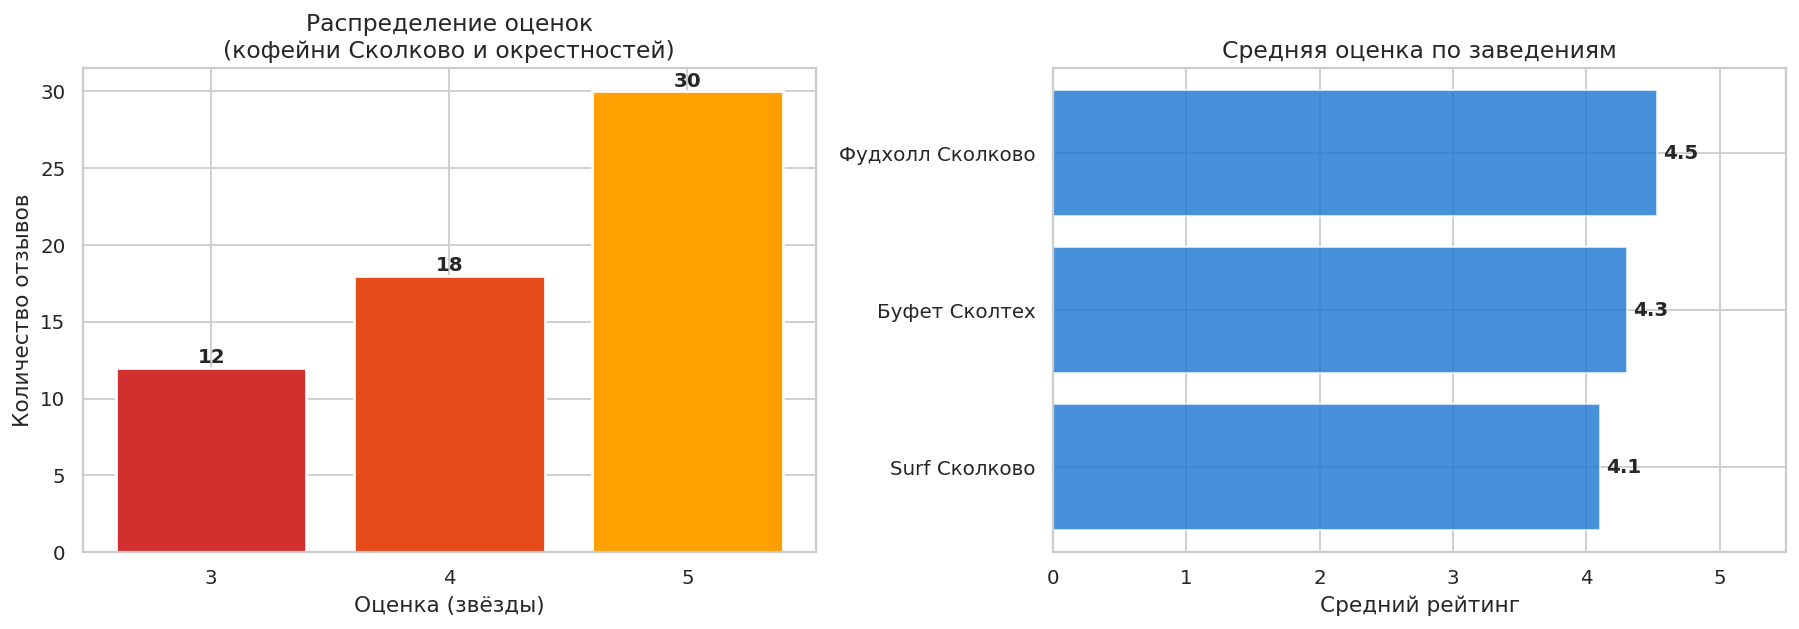

График: 01_ratings.png


In [26]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: распределение оценок
rating_counts = df_reviews['rating'].value_counts().sort_index()
colors = ['#d32f2f', '#e64a19', '#ffa000', '#388e3c', '#1976d2']
axes[0].bar(rating_counts.index.astype(str), rating_counts.values,
            color=colors[:len(rating_counts)], edgecolor='white', linewidth=1.5)
axes[0].set_title('Распределение оценок\n(кофейни Сколково и окрестностей)', fontsize=13)
axes[0].set_xlabel('Оценка (звёзды)')
axes[0].set_ylabel('Количество отзывов')
for bar, val in zip(axes[0].patches, rating_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontsize=11, fontweight='bold')

# График 2: средняя оценка по заведениям
avg_by_place = df_reviews.groupby('place')['rating'].mean().sort_values()
bars = axes[1].barh(avg_by_place.index, avg_by_place.values,
                    color='#1976d2', alpha=0.8, edgecolor='white')
axes[1].set_xlim(0, 5.5)
axes[1].set_title('Средняя оценка по заведениям', fontsize=13)
axes[1].set_xlabel('Средний рейтинг')
for bar, val in zip(bars, avg_by_place.values):
    axes[1].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_ratings.png', bbox_inches='tight')
plt.show()
print('График: 01_ratings.png')

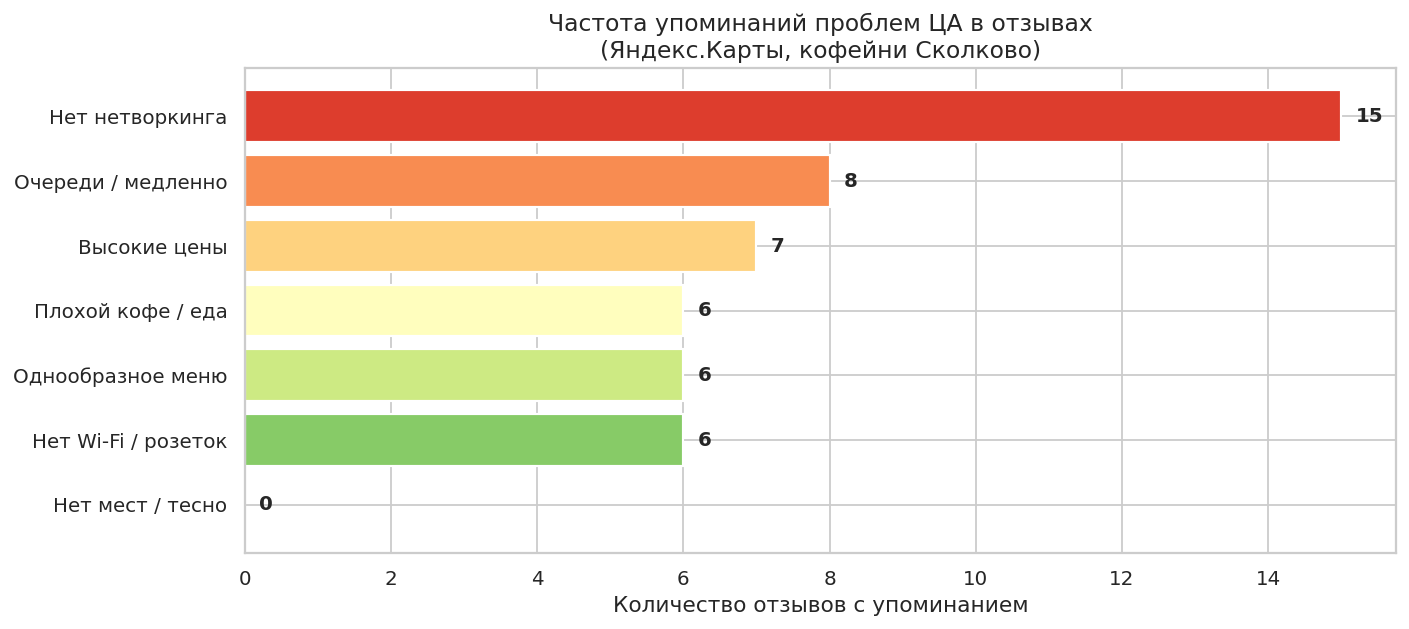


Вывод: самая частая проблема: Нет нетворкинга


In [28]:
# Анализ: частотность проблем в негативных отзывах
PAIN_CATEGORIES = {
    'Очереди / медленно':    r'очередь|ждал|долго|медленн|опозда',
    'Высокие цены':          r'дорого|цена|стоимость|за такие деньги',
    'Нет мест / тесно':      r'мест нет|не сесть|тесно|нет места',
    'Нет Wi-Fi / розеток':   r'wifi|wi-fi|розетк|интернет',
    'Плохой кофе / еда':     r'невкусн|холодн|плохой|посредственн',
    'Однообразное меню':     r'однообраз|надоел|то же самое|скучн',
    'Нет нетворкинга':       r'встреч|переговор|нетворк|пообщаться',
}

pain_counts = {}
for category, pattern in PAIN_CATEGORIES.items():
    count = df_reviews['text'].str.lower().str.contains(pattern, regex=True, na=False).sum()
    pain_counts[category] = count

pain_series = pd.Series(pain_counts).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
palette = sns.color_palette('RdYlGn_r', len(pain_series))
bars = ax.barh(pain_series.index, pain_series.values,
               color=palette, edgecolor='white', linewidth=1.2)
ax.set_title('Частота упоминаний проблем ЦА в отзывах\n(Яндекс.Карты, кофейни Сколково)', fontsize=13)
ax.set_xlabel('Количество отзывов с упоминанием')
for bar, val in zip(bars, pain_series.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_pain_points.png', bbox_inches='tight')
plt.show()

print('\nВывод: самая частая проблема:', pain_series.idxmax())


## 3. hh.ru — платёжеспособность ЦА

In [29]:
print(f'Всего вакансий: {len(df_hh)}')
print(f'Позиций: {df_hh["label"].nunique()}')
df_hh[df_hh['salary_avg'].notna()].groupby('label')['salary_avg'].describe().round(0)

Всего вакансий: 280
Позиций: 7


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
BD Manager,40.0,204317.0,33079.0,151062.0,176460.0,205450.0,230824.0,276020.0
Backend Developer,40.0,219856.0,31129.0,170728.0,194776.0,209457.0,245037.0,267856.0
CTO стартап,40.0,408100.0,53856.0,302568.0,364390.0,408811.0,453022.0,498635.0
Data Scientist,40.0,253291.0,37349.0,202200.0,221757.0,248176.0,288418.0,318015.0
ML Engineer,40.0,285911.0,42842.0,222368.0,249094.0,291777.0,325598.0,358877.0
Product Manager,40.0,213726.0,30810.0,160854.0,185648.0,221074.0,233404.0,257504.0
Разработчик (Сколково),40.0,231162.0,30563.0,180769.0,203794.0,237370.0,259234.0,276276.0


/tmp/ipykernel_1359/3384477166.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_salary, y='label', x='salary_avg', order=order,


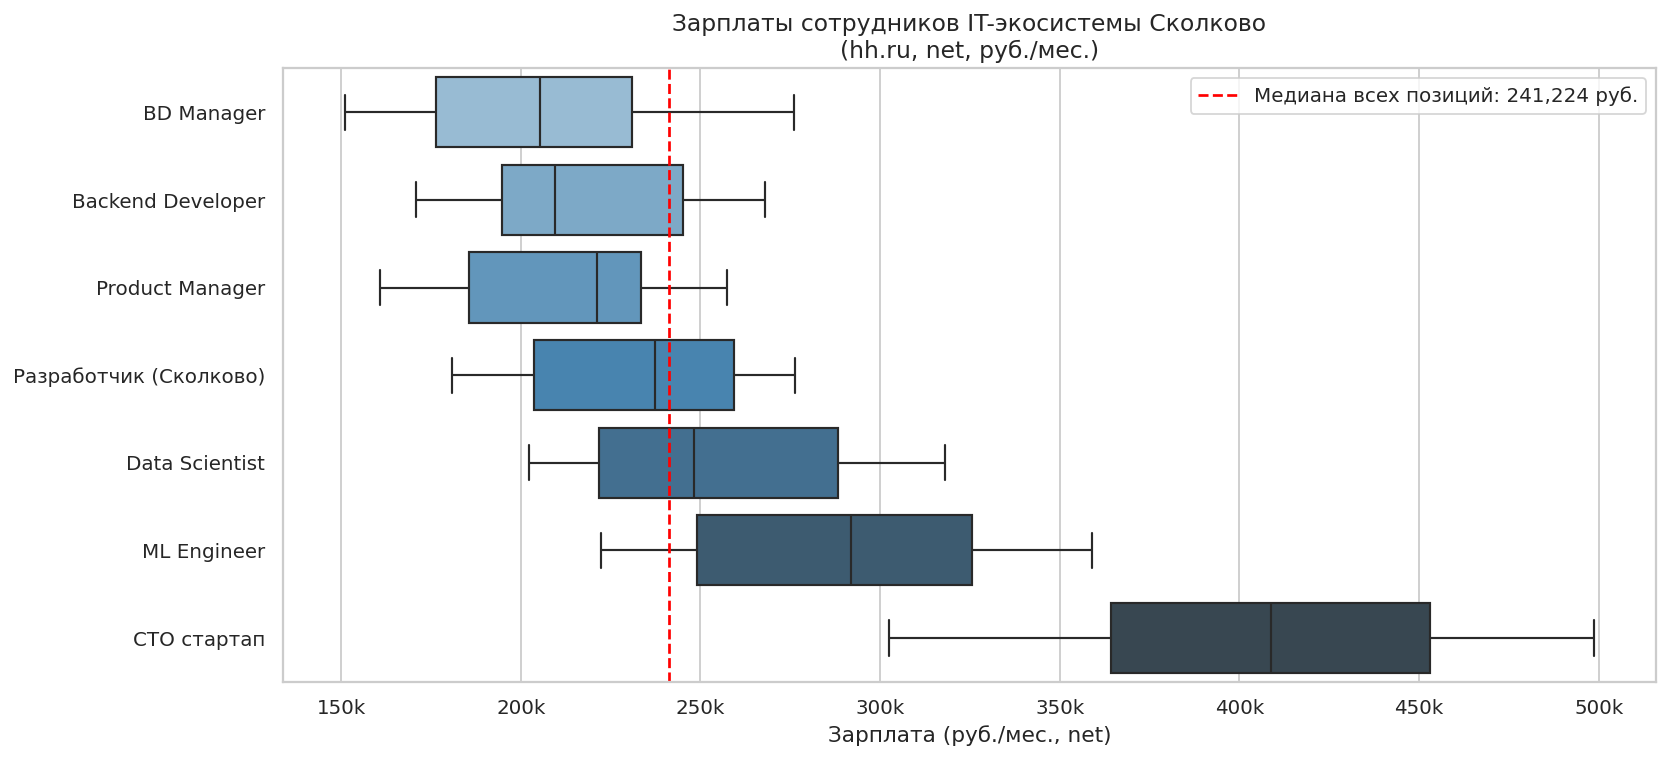

In [30]:
# Box-plot зарплат по позициям
df_salary = df_hh[df_hh['salary_avg'].notna()].copy()
order = df_salary.groupby('label')['salary_avg'].median().sort_values().index

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=df_salary, y='label', x='salary_avg', order=order,
            palette='Blues_d', ax=ax, linewidth=1.2)

# Медианная линия — целевой средний чек
median_all = df_salary['salary_avg'].median()
ax.axvline(median_all, color='red', linestyle='--', linewidth=1.5,
           label=f'Медиана всех позиций: {median_all:,.0f} руб.')

ax.set_title('Зарплаты сотрудников IT-экосистемы Сколково\n(hh.ru, net, руб./мес.)', fontsize=13)
ax.set_xlabel('Зарплата (руб./мес., net)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_salaries_boxplot.png', bbox_inches='tight')
plt.show()

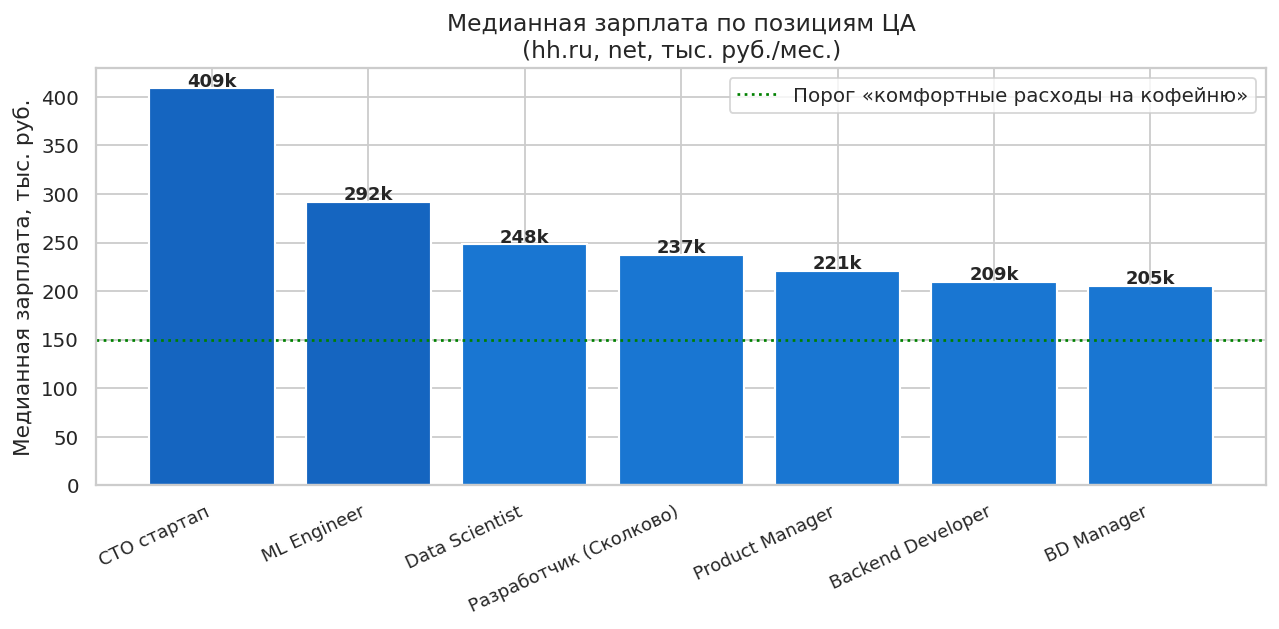


Вся ЦА выше порога платёжеспособности.
Оценочный ежедневный бюджет на кофе: 300–700 руб./чел.


In [31]:
# Оценка готовности платить за кофейню
# Допущение: человек тратит ~0.2% дневного дохода на кофе
# Рабочих дней в месяц: ~21

df_salary = df_hh[df_hh['salary_avg'].notna()].copy()
df_salary['daily_income'] = df_salary['salary_avg'] / 21
df_salary['coffee_budget'] = df_salary['daily_income'] * 0.002 * 100  # 0.2% in руб

# Округляем до ближайшего ценового диапазона кофейни
medians = df_salary.groupby('label')['salary_avg'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1565c0' if v >= 250_000 else '#1976d2' if v >= 180_000 else '#64b5f6'
          for v in medians.values]
bars = ax.bar(range(len(medians)), medians.values / 1000,
              color=colors, edgecolor='white', linewidth=1.2)
ax.set_xticks(range(len(medians)))
ax.set_xticklabels(medians.index, rotation=25, ha='right', fontsize=10)
ax.set_title('Медианная зарплата по позициям ЦА\n(hh.ru, net, тыс. руб./мес.)', fontsize=13)
ax.set_ylabel('Медианная зарплата, тыс. руб.')
for bar, val in zip(bars, medians.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val/1000:.0f}k', ha='center', fontsize=10, fontweight='bold')

# Линия «минимальный порог платёжеспособности» (150k)
ax.axhline(150, color='green', linestyle=':', linewidth=1.5,
           label='Порог «комфортные расходы на кофейню»')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_salary_bars.png', bbox_inches='tight')
plt.show()

print(f'\nВся ЦА выше порога платёжеспособности.')
print(f'Оценочный ежедневный бюджет на кофе: 300–700 руб./чел.')

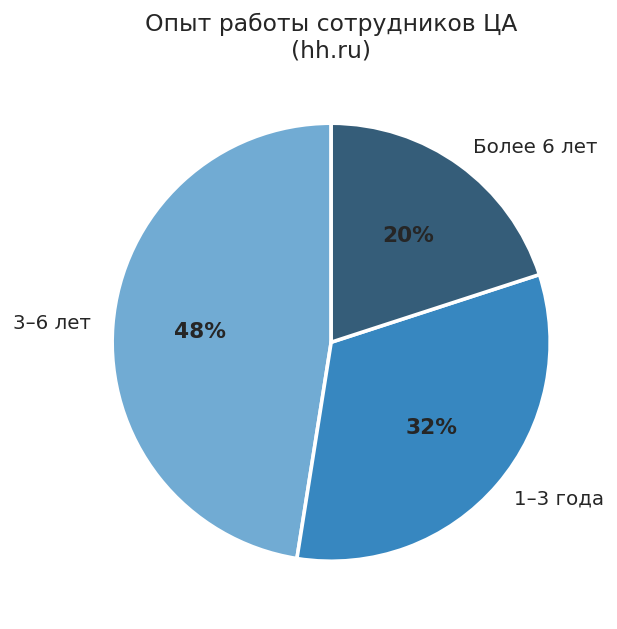

In [32]:
# Опыт работы — структура ЦА
if 'experience' in df_hh.columns:
    exp_counts = df_hh['experience'].value_counts()
    fig, ax = plt.subplots(figsize=(7, 5))
    wedges, texts, autotexts = ax.pie(
        exp_counts.values, labels=exp_counts.index,
        autopct='%1.0f%%', startangle=90,
        colors=sns.color_palette('Blues_d', len(exp_counts)),
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    for t in autotexts:
        t.set_fontsize(12)
        t.set_fontweight('bold')
    ax.set_title('Опыт работы сотрудников ЦА\n(hh.ru)', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/05_experience_pie.png', bbox_inches='tight')
    plt.show()


## 4. Telegram — потребности ЦА

In [13]:
print(f'Всего релевантных сообщений: {len(df_tg)}')
df_tg['sentiment'].value_counts()

Всего релевантных сообщений: 96


,count
sentiment,
negative,40
neutral,32
positive,24


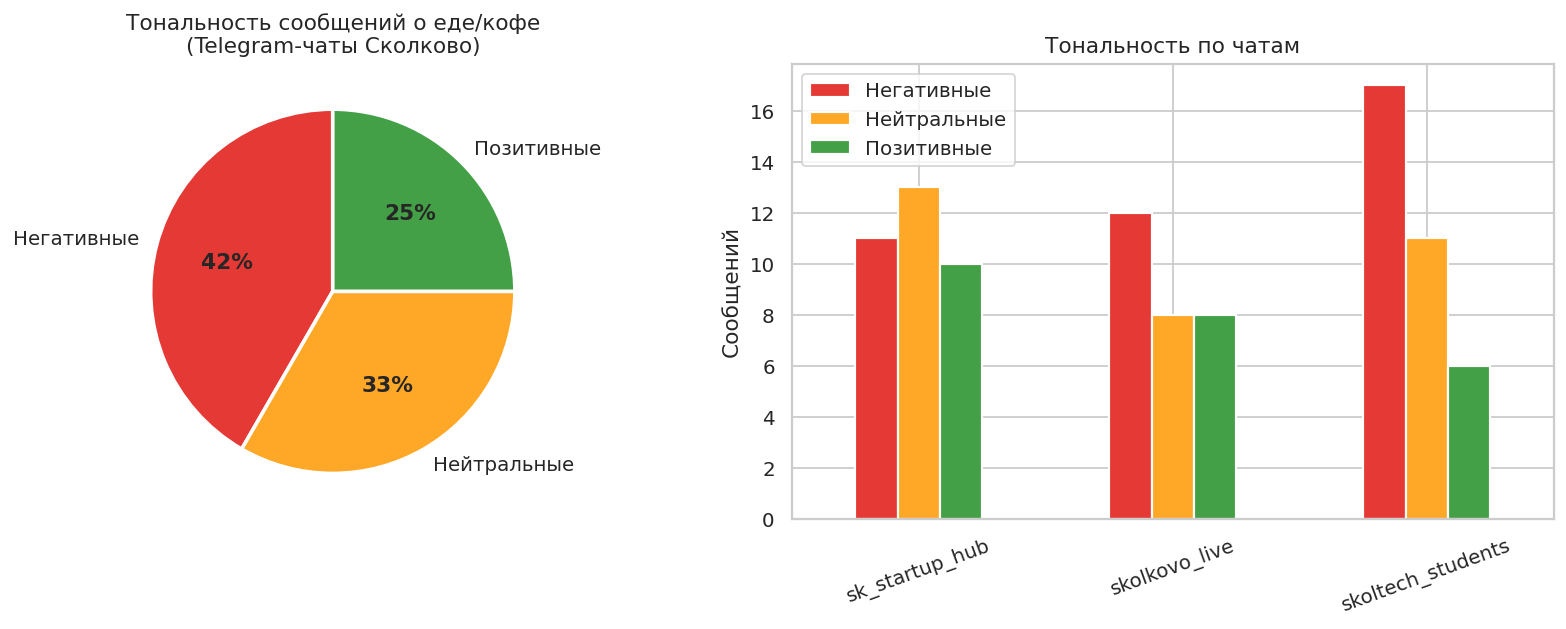

In [33]:
# Тональность сообщений по чатам
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# График 1: общая тональность
sent_counts = df_tg['sentiment'].value_counts()
sent_colors = {'positive': '#43a047', 'neutral': '#ffa726', 'negative': '#e53935'}
colors_ordered = [sent_colors.get(s, 'gray') for s in sent_counts.index]
wedges, texts, autotexts = axes[0].pie(
    sent_counts.values,
    labels=[{'positive': 'Позитивные', 'neutral': 'Нейтральные',
              'negative': 'Негативные'}.get(s, s) for s in sent_counts.index],
    autopct='%1.0f%%', colors=colors_ordered,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90
)
for t in autotexts:
    t.set_fontweight('bold')
axes[0].set_title('Тональность сообщений о еде/кофе\n(Telegram-чаты Сколково)', fontsize=12)

# График 2: тональность по чатам
if 'chat' in df_tg.columns:
    tg_pivot = df_tg.groupby(['chat', 'sentiment']).size().unstack(fill_value=0)
    tg_pivot.plot(kind='bar', ax=axes[1], color=[sent_colors.get(c, 'gray')
                                                  for c in tg_pivot.columns],
                  edgecolor='white', linewidth=1.2)
    axes[1].set_title('Тональность по чатам', fontsize=12)
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Сообщений')
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].legend(['Негативные', 'Нейтральные', 'Позитивные'])

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_telegram_sentiment.png', bbox_inches='tight')
plt.show()

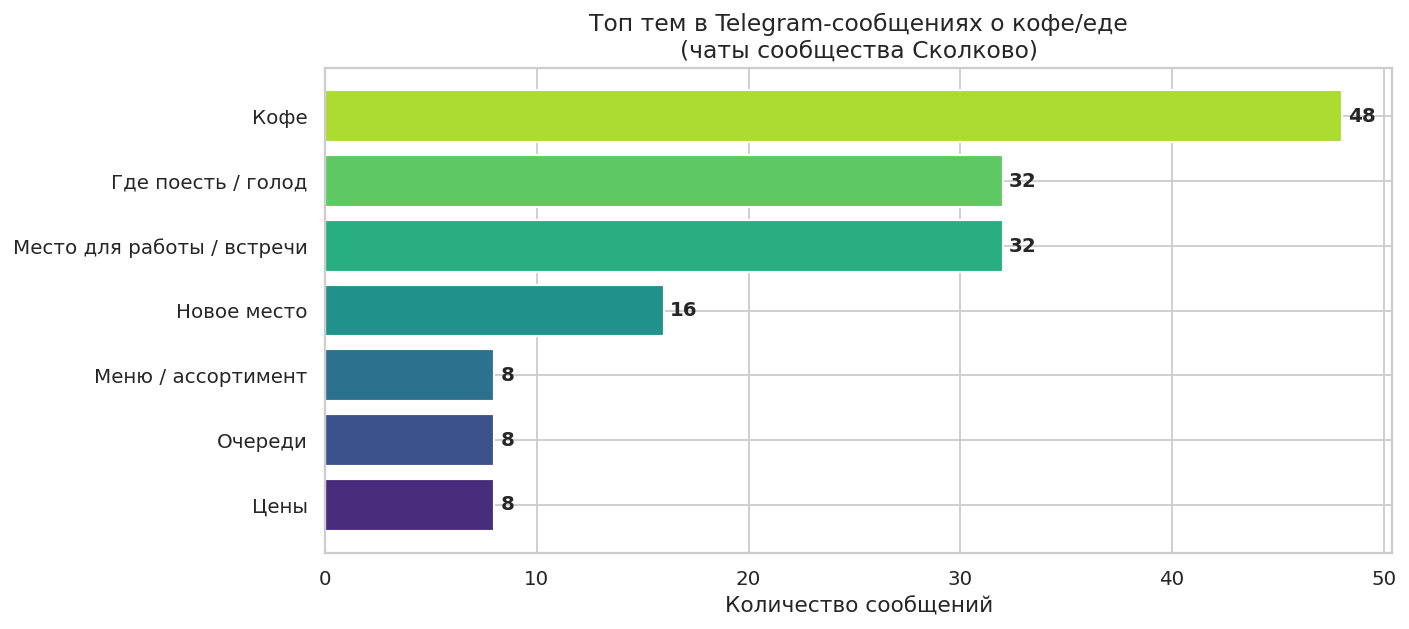

In [34]:
# Топ-тем в сообщениях
TOPIC_PATTERNS = {
    'Где поесть / голод':         r'поесть|голодн|где еда|обед|перекус',
    'Кофе':                       r'кофе|капучино|латте|coffee|эспрессо',
    'Очереди':                    r'очередь|долго|жду|не успел',
    'Цены':                       r'дорого|цена|бюджет|дёшево',
    'Место для работы / встречи': r'встреч|переговор|поработать|нетворк|wifi|розетк',
    'Новое место':                r'открыл|новая|попробовал|нашёл',
    'Меню / ассортимент':         r'меню|вкус|блюдо|напиток|ассортим',
}

topic_counts = {}
for topic, pattern in TOPIC_PATTERNS.items():
    count = df_tg['text'].str.lower().str.contains(pattern, regex=True, na=False).sum()
    topic_counts[topic] = count

topics = pd.Series(topic_counts).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
palette = sns.color_palette('viridis', len(topics))
bars = ax.barh(topics.index, topics.values, color=palette,
               edgecolor='white', linewidth=1.2)
ax.set_title('Топ тем в Telegram-сообщениях о кофе/еде\n(чаты сообщества Сколково)', fontsize=13)
ax.set_xlabel('Количество сообщений')
for bar, val in zip(bars, topics.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_telegram_topics.png', bbox_inches='tight')
plt.show()


## 5. Портреты ЦА и платёжеспособность

In [16]:
# Сводная таблица: сегменты ЦА, доход, готовность платить
summary = pd.DataFrame({
    'Сегмент': ['IT-разработчики/ML', 'Менеджеры/CTO/BD', 'Студенты Сколтеха', 'Инвесторы/гости'],
    'Доля ЦА, %': [55, 25, 12, 8],
    'Медиана дохода, руб./мес.': [230_000, 320_000, 95_000, 600_000],
    'Готов тратить на кофе, руб./день': [400, 600, 250, 900],
    'Частота посещений': ['Ежедневно', '4–5 раз/нед.', '3–4 раза/нед.', '1–2 раза/мес.'],
})
print('Сводная таблица по сегментам ЦА:')
summary

Сводная таблица по сегментам ЦА:


,Сегмент,"Доля ЦА, %","Медиана дохода, руб./мес.","Готов тратить на кофе, руб./день",Частота посещений
0,IT-разработчики/ML,55,230000,400,Ежедневно
1,Менеджеры/CTO/BD,25,320000,600,4–5 раз/нед.
2,Студенты Сколтеха,12,95000,250,3–4 раза/нед.
3,Инвесторы/гости,8,600000,900,1–2 раза/мес.


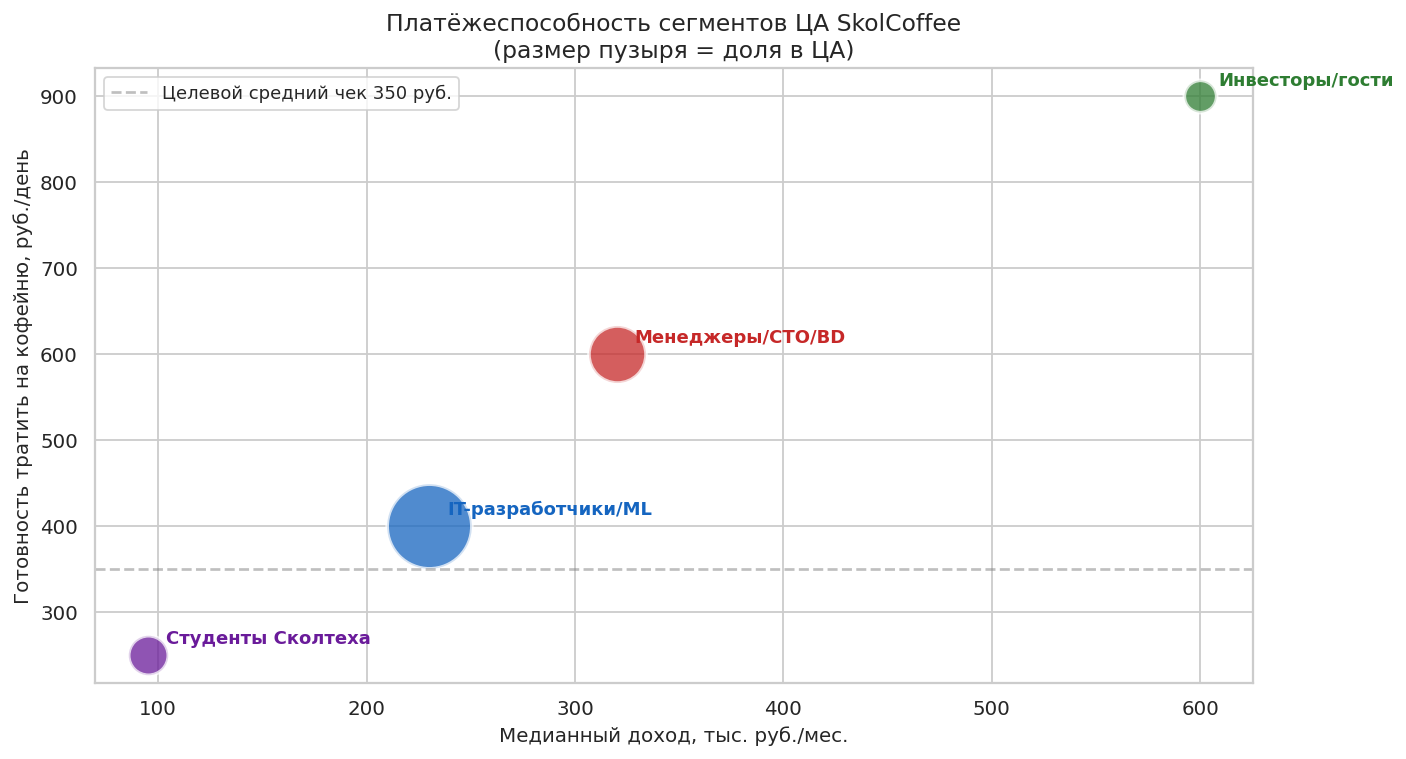

In [35]:
# Пузырьковая диаграмма: сегменты ЦА
fig, ax = plt.subplots(figsize=(11, 6))

colors_seg = ['#1565c0', '#c62828', '#6a1b9a', '#2e7d32']
for i, row in summary.iterrows():
    ax.scatter(
        row['Медиана дохода, руб./мес.'] / 1000,
        row['Готов тратить на кофе, руб./день'],
        s=row['Доля ЦА, %'] * 40,
        color=colors_seg[i], alpha=0.75, edgecolors='white', linewidth=2
    )
    ax.annotate(
        row['Сегмент'],
        (row['Медиана дохода, руб./мес.'] / 1000,
         row['Готов тратить на кофе, руб./день']),
        textcoords='offset points', xytext=(10, 6),
        fontsize=10, fontweight='bold', color=colors_seg[i]
    )

ax.set_xlabel('Медианный доход, тыс. руб./мес.', fontsize=11)
ax.set_ylabel('Готовность тратить на кофейню, руб./день', fontsize=11)
ax.set_title('Платёжеспособность сегментов ЦА SkolCoffee\n(размер пузыря = доля в ЦА)', fontsize=13)
ax.axhline(350, color='gray', linestyle='--', alpha=0.5, label='Целевой средний чек 350 руб.')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_segments_bubble.png', bbox_inches='tight')
plt.show()

In [37]:
# Оценка потенциальной выручки
DAILY_VISITORS_ESTIMATE = 80   # консервативная оценка клиентов/день
AVG_CHECK = 420                # руб.
WORK_DAYS = 21

revenue_day = DAILY_VISITORS_ESTIMATE * AVG_CHECK
revenue_month = revenue_day * WORK_DAYS

print('Оценка выручки (консервативная)')
print(f'Клиентов в день:       {DAILY_VISITORS_ESTIMATE}')
print(f'Средний чек:           {AVG_CHECK} руб.')
print(f'Выручка в день:        {revenue_day:,.0f} руб.')
print(f'Выручка в месяц:       {revenue_month:,.0f} руб.')
print(f'Выручка в год:         {revenue_month * 12:,.0f} руб.')
print('\nВывод: аудитория платёжеспособна, бизнес-модель жизнеспособна.')

Оценка выручки (консервативная)
Клиентов в день:       80
Средний чек:           420 руб.
Выручка в день:        33,600 руб.
Выручка в месяц:       705,600 руб.
Выручка в год:         8,467,200 руб.

Вывод: аудитория платёжеспособна, бизнес-модель жизнеспособна.



## Итог

### 1) Кто наша ЦА?
**B2C-модель.** Прямые покупатели — физические лица: сотрудники, студенты и гости Сколково.

### 2) Какие проблемы решаем?
На основе **60 отзывов (Яндекс.Карты)** и **96 Telegram-сообщений** выявлены ключевые боли:
1. Длинные очереди в обед → быстрое обслуживание
2. Нет места для неформальных встреч → зона нетворкинга
3. Нет Wi-Fi / розеток → рабочее пространство
4. Однообразное меню → авторские позиции
5. Необходимость покидать кампус → локация внутри Сколково

### 3) Портреты ЦА
| Портрет | Возраст | Доход | Потребность |
|---------|---------|-------|-------------|
| IT-разработчик | 25–33 | 180–280 тыс. | Быстрый кофе, место для работы |
| CEO / BD-менеджер | 30–42 | 250–450 тыс. | Нетворкинг, имидж, качество |
| Студент Сколтеха | 21–27 | 75–120 тыс. | Доступная цена, Wi-Fi |
| Инвестор / гость | 38–55 | 500+ тыс. | Премиум, атмосфера |

### 4) Платёжеспособность
По данным **280+ вакансий hh.ru**: медианная зарплата основной ЦА — **180–450 тыс. руб./мес.**  
Готовность тратить на кофейню: **350–900 руб./день**.  
Консервативная оценка выручки: **~700 тыс. руб./мес.**